# RynnBrain 1.1 Inference Recipes

## Section 8: 3D Grounding

In this section, we demonstrate RynnBrain's ability to perform 3D object grounding. Given a single RGB image and camera intrinsics, RynnBrain predicts 3D bounding boxes (center position, dimensions, and orientation) in camera coordinates. This enables precise spatial understanding of objects in 3D space from 2D images.

We use images from the **SUN RGB-D** dataset with real camera intrinsics.

### [Setup] Load visualization utils

In [ ]:
import os
ROOT_PATH="" # set the path to root dir
assert ROOT_PATH != "", "Please set ROOT_PATH to the cookbooks directory."
os.chdir(ROOT_PATH)

import glob
import json
import re
import io
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPyImage
import cv2

# Box edge connectivity for 8-corner representation
BOX_EDGES = [
    (0, 1), (2, 3), (4, 5), (6, 7),  # along x-axis
    (0, 2), (1, 3), (4, 6), (5, 7),  # along y-axis
    (0, 4), (1, 5), (2, 6), (3, 7),  # along z-axis
]

def euler_to_rotation_matrix(pitch, yaw, roll):
    """Convert normalized Euler angles [-1, 1] to rotation matrix R = Rz @ Ry @ Rx.
    pitch, yaw, roll are normalized [-1, 1] mapping to [-180, 180] degrees."""
    p = np.deg2rad(pitch * 180)
    y = np.deg2rad(yaw * 180)
    r = np.deg2rad(roll * 180)
    cp, sp = np.cos(p), np.sin(p)
    cy, sy = np.cos(y), np.sin(y)
    cr, sr = np.cos(r), np.sin(r)
    Rx = np.array([[1, 0, 0], [0, cp, -sp], [0, sp, cp]])
    Ry = np.array([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]])
    Rz = np.array([[cr, -sr, 0], [sr, cr, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx

def box3d_corners_from_params(center, dims, R):
    """Build 8 corners from center, dims=[x_size, y_size, z_size], and rotation matrix."""
    w, h, l = dims[0], dims[1], dims[2]
    x = np.array([w / 2, 0, 0])
    y = np.array([0, h / 2, 0])
    z = np.array([0, 0, l / 2])
    corners = np.array([
        -x - y - z, -x - y + z, -x + y - z, -x + y + z,
        +x - y - z, +x - y + z, +x + y - z, +x + y + z,
    ])
    corners = (R @ corners.T).T + np.array(center)
    return corners

def project_corners_to_2d(corners, K):
    """Project 8x3 corners to 2D pixel coordinates using intrinsics K (3x3)."""
    pts_2d = []
    for pt in corners:
        if pt[2] <= 0 or not np.isfinite(pt).all():
            pts_2d.append(None)
            continue
        px = K[0, 0] * (pt[0] / pt[2]) + K[0, 2]
        py = K[1, 1] * (pt[1] / pt[2]) + K[1, 2]
        if not np.isfinite(px) or not np.isfinite(py):
            pts_2d.append(None)
            continue
        pts_2d.append((int(round(px)), int(round(py))))
    return pts_2d

def draw_box_edges_on_image(img, pts_2d, color=(0, 0, 255), thickness=2):
    """Draw 3D box edges on OpenCV BGR image."""
    for i, j in BOX_EDGES:
        if i < len(pts_2d) and j < len(pts_2d):
            if pts_2d[i] is not None and pts_2d[j] is not None:
                cv2.line(img, pts_2d[i], pts_2d[j], color, thickness)

def parse_3d_groundings(output_text):
    """Parse 3D bounding boxes from model output.
    Extracts <3D Grounding> tags: cx, cy, cz, x_size, y_size, z_size, pitch, yaw, roll."""
    results = []
    for match in re.findall(r"<3D Grounding>\s*(.*?)\s*</3D Grounding>", output_text):
        try:
            values = [float(v.strip()) for v in match.split(",")]
            if len(values) == 9:
                results.append(values)
        except ValueError:
            continue
    # Fallback: malformed tags
    if not results:
        for m in re.finditer(
            r"<+\s*([-\d.]+)\s*,\s*([-\d.]+)\s*,\s*([-\d.]+)\s*,"
            r"\s*([-\d.]+)\s*,\s*([-\d.]+)\s*,\s*([-\d.]+)\s*,"
            r"\s*([-\d.]+)\s*,\s*([-\d.]+)\s*,\s*([-\d.]+)\s*>",
            output_text,
        ):
            values = [float(m.group(i)) for i in range(1, 10)]
            results.append(values)
    parsed_boxes = []
    for box_9 in results:
        cx, cy, cz = box_9[0], box_9[1], box_9[2]
        x_size, y_size, z_size = box_9[3], box_9[4], box_9[5]
        pitch, yaw, roll = box_9[6], box_9[7], box_9[8]
        R = euler_to_rotation_matrix(pitch, yaw, roll)
        center = np.array([cx, cy, cz])
        dims = np.array([x_size, y_size, z_size])
        corners = box3d_corners_from_params(center, dims, R)
        parsed_boxes.append({
            "center": [cx, cy, cz],
            "dims": [x_size, y_size, z_size],
            "euler": [pitch, yaw, roll],
            "corners": corners.tolist(),
        })
    return parsed_boxes

def format_K(K):
    """Format 3x3 intrinsics matrix as string for prompt."""
    rows = []
    for row in K:
        rows.append("[" + ", ".join(f"{v:.2f}" for v in row) + "]")
    return "[" + ", ".join(rows) + "]"

def build_3d_grounding_prompt(category_name, K_str):
    """Build the 3D grounding prompt, matching the benchmark prompt template.
    Includes <think>\n\n
</think>

\n\n to close thinking mode (standard for this model)."""
    prompt = f"""Find all {category_name} in this image.

The camera intrinsics matrix is:
{K_str}

Predict 3D bounding boxes in the camera coordinate system, where:
- x points to the right
- y points downward
- z points forward

For each object, return:
<3D Grounding> cx, cy, cz, x_size, y_size, z_size, pitch, yaw, roll </3D Grounding>

Definitions:
- cx, cy, cz: 3D coordinates of the box center in the camera coordinate system, in meters
- x_size, y_size, z_size: box dimensions in the box local coordinate system, in meters
  - x_size: extent along the local x-axis
  - y_size: extent along the local y-axis
  - z_size: extent along the local z-axis
- pitch: rotation around the camera x-axis, in radians (range: -1 to 1, corresponding to -180 to 180 degrees)
- yaw: rotation around the camera y-axis, in radians (range: -1 to 1, corresponding to -180 to 180 degrees)
- roll: rotation around the camera z-axis, in radians (range: -1 to 1, corresponding to -180 to 180 degrees)

Constraints:
- x_size >= z_size
- Use meters for cx, cy, cz, x_size, y_size, z_size
- Use radians for pitch, yaw, roll, with each value in the range [-1, 1]
<think>\n\n</think>\n\n
"""
    return prompt

def run_inference(wrapper, image_path, prompt, processing_params, sampling_params):
    """Run model inference using the RynnScale inference wrapper.

    This uses the same pipeline as the benchmark evaluation:
    apply_chat_template -> load_images -> process_images -> process_text -> generate

    Args:
        wrapper: RynnScale inference wrapper (e.g. Qwen3_5InferenceWrapper)
        image_path: path to the input image
        prompt: text prompt string
        processing_params: dict with image/video processing params
        sampling_params: dict with generation params

    Returns:
        output_text: model response string (with <think>...</think> stripped)
    """
    # Build conversation
    conversation = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image_path},
            {"type": "text", "text": prompt},
        ],
    }]

    # Apply chat template (enable_thinking=False matches benchmark)
    text = wrapper.apply_chat_template(conversation, enable_thinking=False)

    # Load and process images (smart_resize for proper resolution)
    images = wrapper.load_images([image_path], processing_params)
    image_inputs = wrapper.process_images(images, processing_params)

    # Process text with image token expansion
    model_inputs = wrapper.process_text(text, image_inputs=image_inputs, video_inputs={})
    model_inputs = model_inputs.to(wrapper.model.device)

    # Generate with greedy decoding
    outputs = wrapper.generate(model_inputs, sampling_params)
    output_text = outputs[0]

    # Strip <think>...</think> content: keep only the final answer
    if "</think>" in output_text:
        output_text = output_text.split("</think>")[-1].strip()
    return output_text


def visualize_3d_grounding(image_path, K, parsed_boxes, category_name="object"):
    """Create single-panel visualization of 3D grounding results.
    
    Only shows the image with projected 3D boxes.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Failed to load image: {image_path}")
        return
    K = np.array(K, dtype=np.float64)
    pred_corners_list = [np.array(pb["corners"]) for pb in parsed_boxes]
    
    # Draw boxes on image
    for corners in pred_corners_list:
        pts = project_corners_to_2d(corners, K)
        draw_box_edges_on_image(img, pts, color=(0, 0, 255), thickness=2)
    
    label = f"{category_name} | Pred={len(parsed_boxes)} boxes"
    cv2.putText(img, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                (255, 255, 255), 2)
    
    # Create figure with single subplot
    plt.figure(figsize=(12, 10), dpi=120)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"3D Grounding: {category_name} | {len(parsed_boxes)} predicted boxes", 
              fontsize=12)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Load SUN RGB-D camera info
with open("assets/3d_grounding/images/sunrgbd_cam_infos.json", "r") as f:
    cam_infos = json.load(f)
print("Loaded SUN RGB-D camera info:", list(cam_infos.keys()))
for name, info in cam_infos.items():
    if isinstance(info.get("benchmark_score"), (int, float)):
        print(f"  {name} ({info['category']}, benchmark IoU={info['benchmark_score']:.3f})")
    else:
        print(f"  {name} ({info['category']})")

Loaded SUN RGB-D camera info: ['chair_sunrgbd.jpg', 'bed_sunrgbd.jpg', 'table_sunrgbd.jpg']
  chair_sunrgbd.jpg (chair, benchmark IoU=0.893)
  bed_sunrgbd.jpg (bed, benchmark IoU=0.861)
  table_sunrgbd.jpg (table, benchmark IoU=0.867)


### [General] Load Model and Processor

In [ ]:
import sys, torch
# sys.path.insert(0, "/path/to/RynnScale") # change the dir to your RynnScale path
sys.path.insert(0, "/mnt/workspace/workgroup/wangzhikai/RynnScale")
from rynn_scale.inference_wrappers import build_inference_wrapper

model_path = "Alibaba-DAMO-Academy/RynnBrain-8B"

# Build inference wrapper — matches the benchmark pipeline exactly
wrapper = build_inference_wrapper(
    model_type="qwen3_5",
    model_path=model_path,
    dtype=torch.bfloat16,
    attn_implementation="sdpa",
)
_ = wrapper.model     # force load
_ = wrapper.processor  # force load

# Processing and sampling params from the benchmark evaluation
PROCESSING_PARAMS = {
    "image_max_pixels": 16777216,
    "image_min_pixels": 16384,
    "video_max_pixels": 16777216,
    "video_min_pixels": 16384,
    "fps": 1,
    "max_frames": 180,
}
SAMPLING_PARAMS = {
    "max_new_tokens": 512,
    "temperature": 0.0,
    "top_p": 0.95,
    "top_k": 50,
}
print("Model loaded successfully")

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

Model loaded successfully


### Single Image 3D Grounding Example:

1. Load and visualize the image

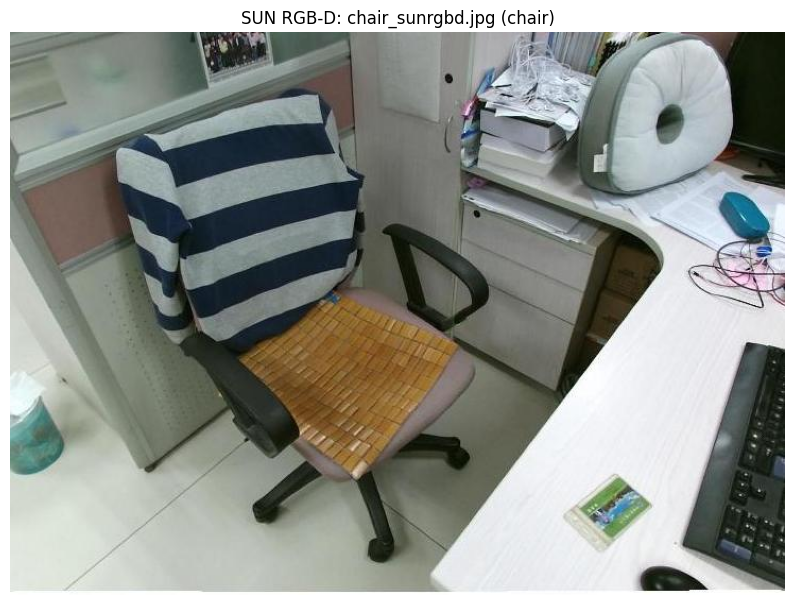

Image size: (730, 530)
Camera intrinsics K:
[[529.5   0.  365. ]
 [  0.  529.5 265. ]
 [  0.    0.    1. ]]


In [3]:
# Load SUN RGB-D test image and camera intrinsics
image_path = "assets/3d_grounding/images/chair_sunrgbd.jpg"
category_name = "chair"

image_name = os.path.basename(image_path)
cam_info = cam_infos[image_name]
fx, fy = cam_info["fx"], cam_info["fy"]
cx, cy = cam_info["cx"], cam_info["cy"]

# Build 3x3 intrinsics matrix
K = np.array([
    [fx, 0.0, cx],
    [0.0, fy, cy],
    [0.0, 0.0, 1.0]
])

# Display image
img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f"SUN RGB-D: {image_name} ({category_name})")
plt.axis("off")
plt.show()

print(f"Image size: {img.size}")
print(f"Camera intrinsics K:\n{K}")

2. Generate messages

In [4]:
# Build prompt with camera intrinsics and 3D grounding instructions
K_str = format_K(K)
prompt = build_3d_grounding_prompt(category_name, K_str)

# Build conversation messages
content = [
    {"type": "image", "image": image_path},
    {"type": "text", "text": prompt}
]

messages = [
    {
        "role": "user",
        "content": content
    }
]

print("Prompt preview:")
print(prompt)

Prompt preview:
Find all chair in this image.

The camera intrinsics matrix is:
[[529.50, 0.00, 365.00], [0.00, 529.50, 265.00], [0.00, 0.00, 1.00]]

Predict 3D bounding boxes in the camera coordinate system, where:
- x points to the right
- y points downward
- z points forward

For each object, return:
<3D Grounding> cx, cy, cz, x_size, y_size, z_size, pitch, yaw, roll </3D Grounding>

Definitions:
- cx, cy, cz: 3D coordinates of the box center in the camera coordinate system, in meters
- x_size, y_size, z_size: box dimensions in the box local coordinate system, in meters
  - x_size: extent along the local x-axis
  - y_size: extent along the local y-axis
  - z_size: extent along the local z-axis
- pitch: rotation around the camera x-axis, in radians (range: -1 to 1, corresponding to -180 to 180 degrees)
- yaw: rotation around the camera y-axis, in radians (range: -1 to 1, corresponding to -180 to 180 degrees)
- roll: rotation around the camera z-axis, in radians (range: -1 to 1, corre

3. Infer with RynnBrain

In [5]:
# Run inference using the RynnScale wrapper (matches benchmark pipeline exactly)
output_text = run_inference(wrapper, image_path, prompt, PROCESSING_PARAMS, SAMPLING_PARAMS)

print("Model output:")
print(output_text)

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Model output:
<3D Grounding> -0.15, 0.05, 1.45, 0.72, 1.00, 0.68, 0.28, 0.15, 0.17 </3D Grounding>



4. Visualization

Parsed 1 3D box(es)

Box 1:
  Center: [-0.150, 0.050, 1.450] m
  Dims:   [0.720, 1.000, 0.680] m
  Euler:  [0.280, 0.150, 0.170] (normalized)


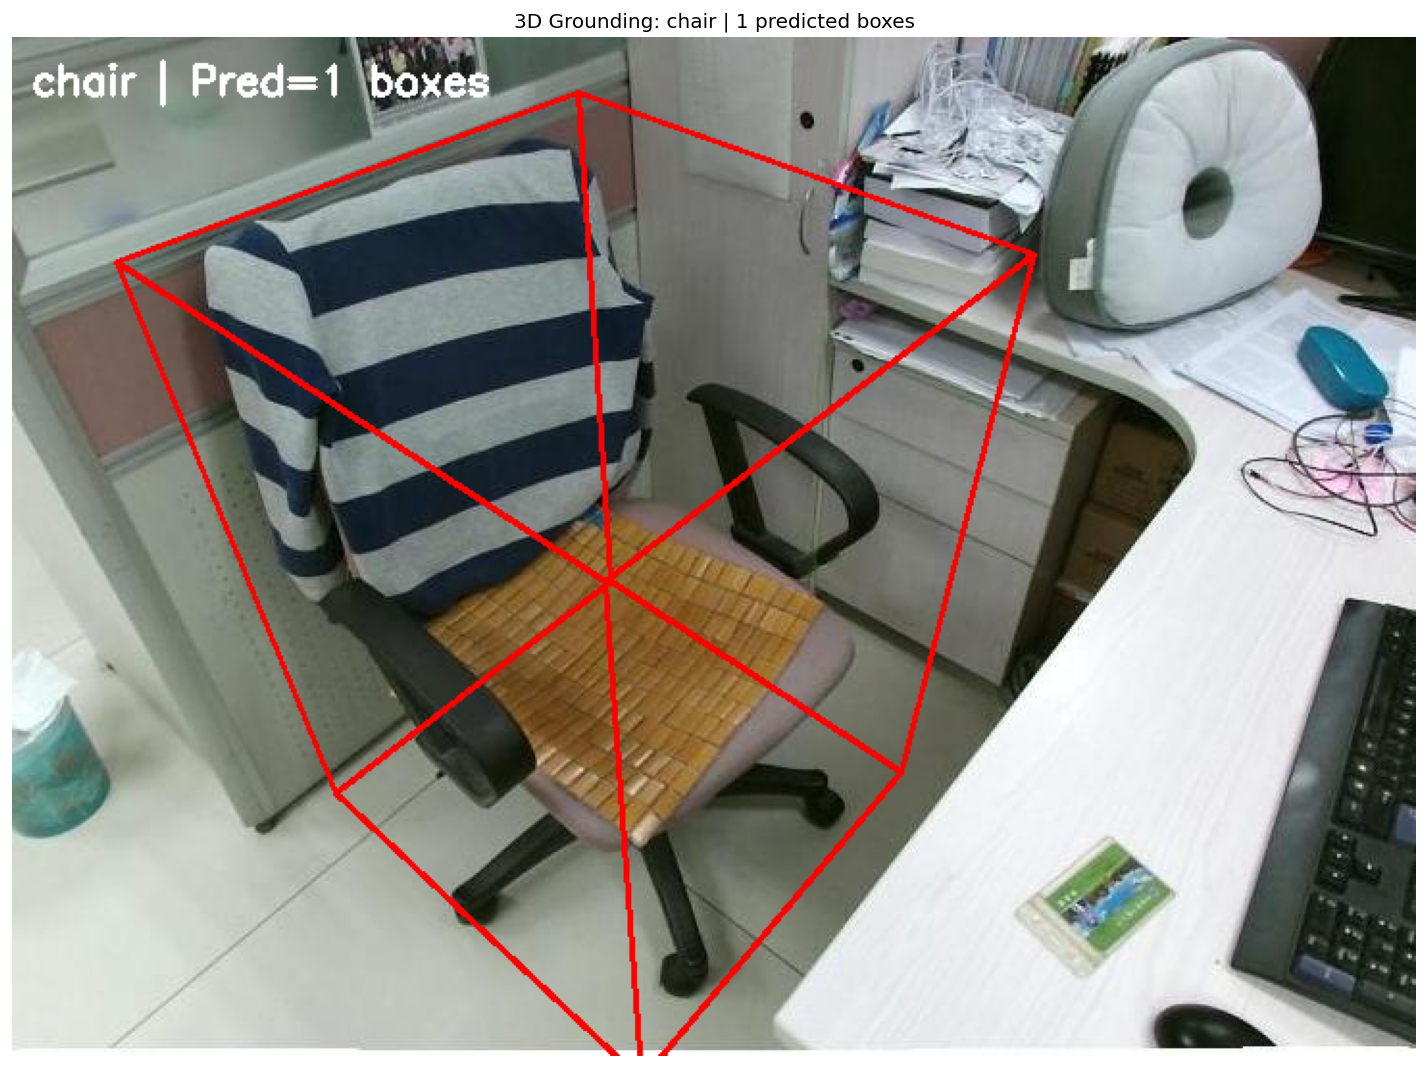

In [12]:
# Parse 3D boxes from output
parsed_boxes = parse_3d_groundings(output_text)

print(f"Parsed {len(parsed_boxes)} 3D box(es)")
for i, box in enumerate(parsed_boxes):
    print(f"\nBox {i+1}:")
    print(f"  Center: [{box['center'][0]:.3f}, {box['center'][1]:.3f}, {box['center'][2]:.3f}] m")
    print(f"  Dims:   [{box['dims'][0]:.3f}, {box['dims'][1]:.3f}, {box['dims'][2]:.3f}] m")
    print(f"  Euler:  [{box['euler'][0]:.3f}, {box['euler'][1]:.3f}, {box['euler'][2]:.3f}] (normalized)")

# Visualize
if parsed_boxes:
    visualize_3d_grounding(image_path, K, parsed_boxes, category_name)
else:
    print("No 3D boxes parsed from output")

### Multi-Category Example:

This example demonstrates detecting different object categories across SUN RGB-D scenes.

1. Detect bed

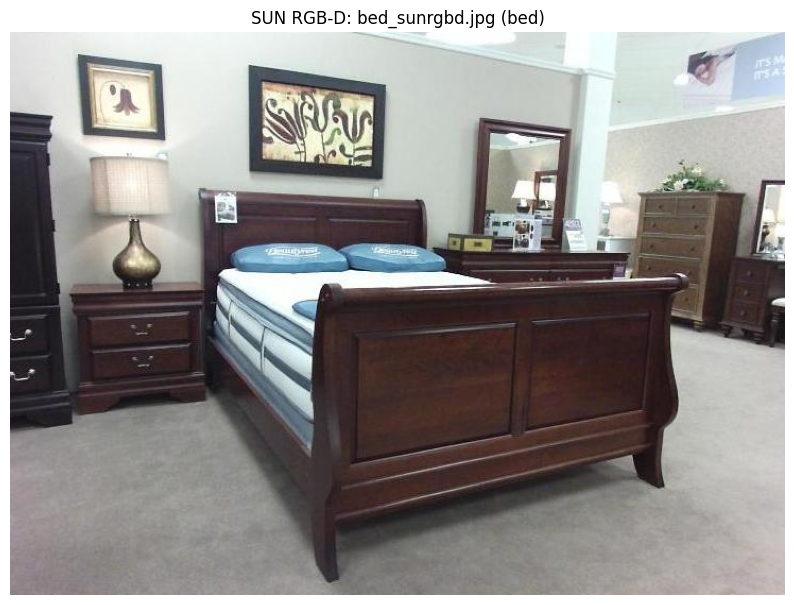

In [7]:
# Load bed scene
scene_image = "assets/3d_grounding/images/bed_sunrgbd.jpg"
scene_name = os.path.basename(scene_image)
cam_info = cam_infos[scene_name]
K_bed = np.array([
    [cam_info["fx"], 0.0, cam_info["cx"]],
    [0.0, cam_info["fy"], cam_info["cy"]],
    [0.0, 0.0, 1.0]
])

# Display
img_scene = Image.open(scene_image).convert("RGB")
plt.figure(figsize=(10, 8))
plt.imshow(img_scene)
plt.title(f"SUN RGB-D: {scene_name} (bed)")
plt.axis("off")
plt.show()

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


<3D Grounding> -0.01, 0.01, 3.01, 2.15, 1.32, 1.65, 0.11, 0.33, 0.10 </3D Grounding>


Detected 1 bed(s)


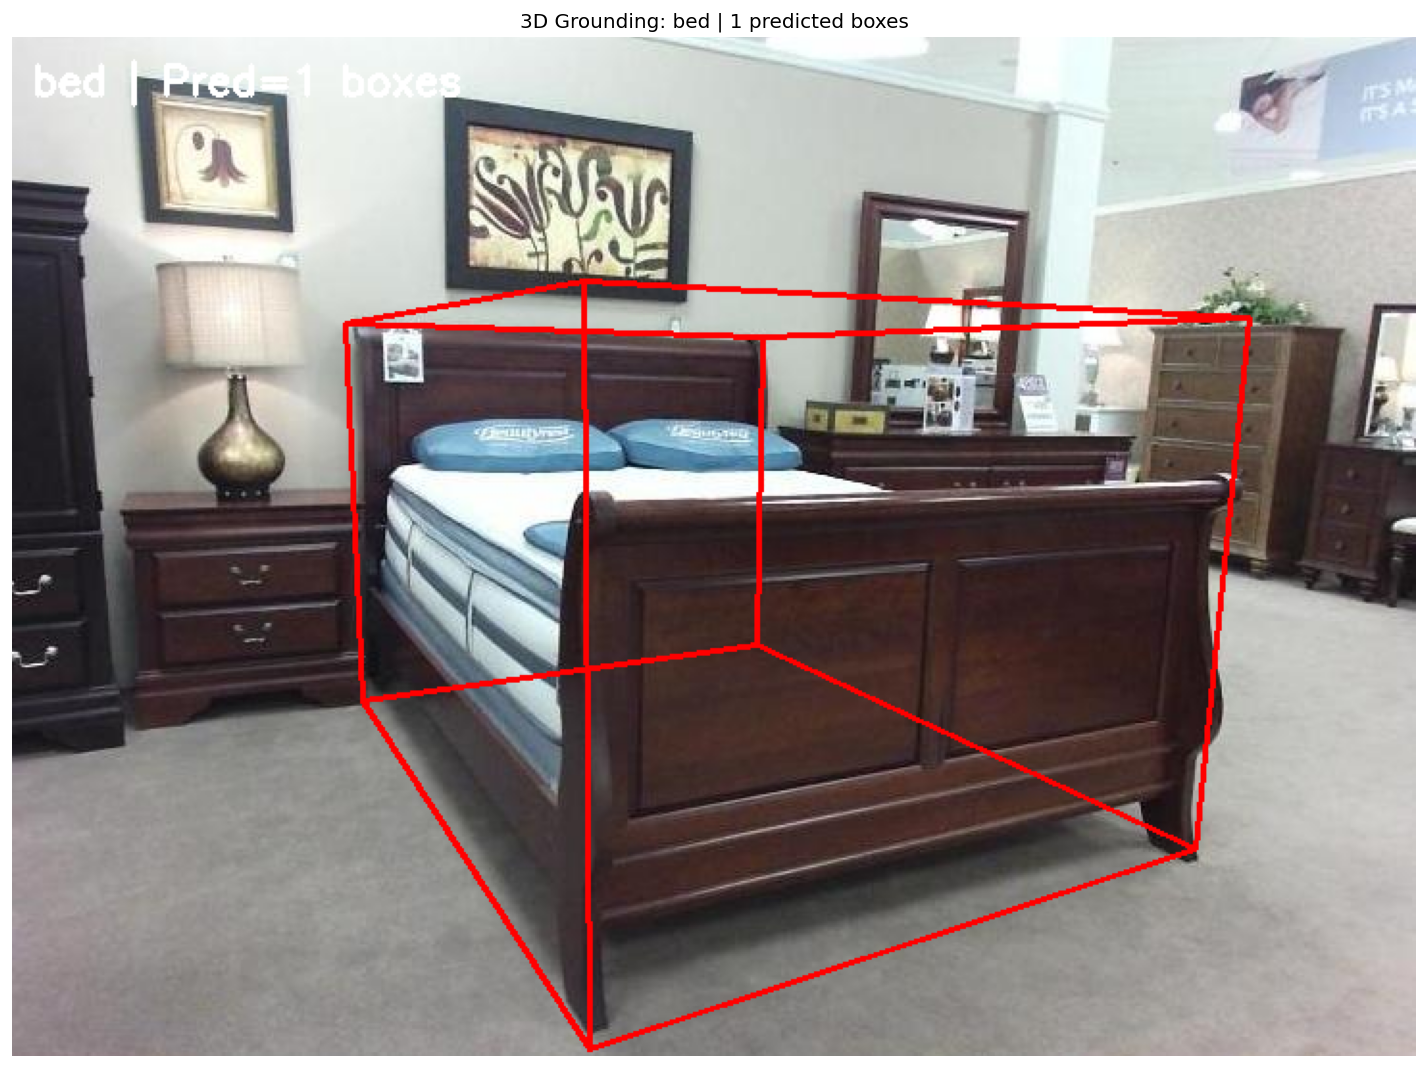

In [13]:
# Detect bed
cat1 = "bed"
K_str_bed = format_K(K_bed)
prompt = build_3d_grounding_prompt(cat1, K_str_bed)

# Inference
output_text = run_inference(wrapper, scene_image, prompt, PROCESSING_PARAMS, SAMPLING_PARAMS)
print(output_text)

# Parse and visualize
parsed_boxes = parse_3d_groundings(output_text)
print(f"\nDetected {len(parsed_boxes)} {cat1}(s)")

if parsed_boxes:
    visualize_3d_grounding(scene_image, K_bed, parsed_boxes, cat1)

2. Detect table

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


<3D Grounding> 0.21, -0.10, 2.02, 1.00, 0.75, 0.75, 0.22, 0.15, 0.11 </3D Grounding>


Detected 1 table(s)


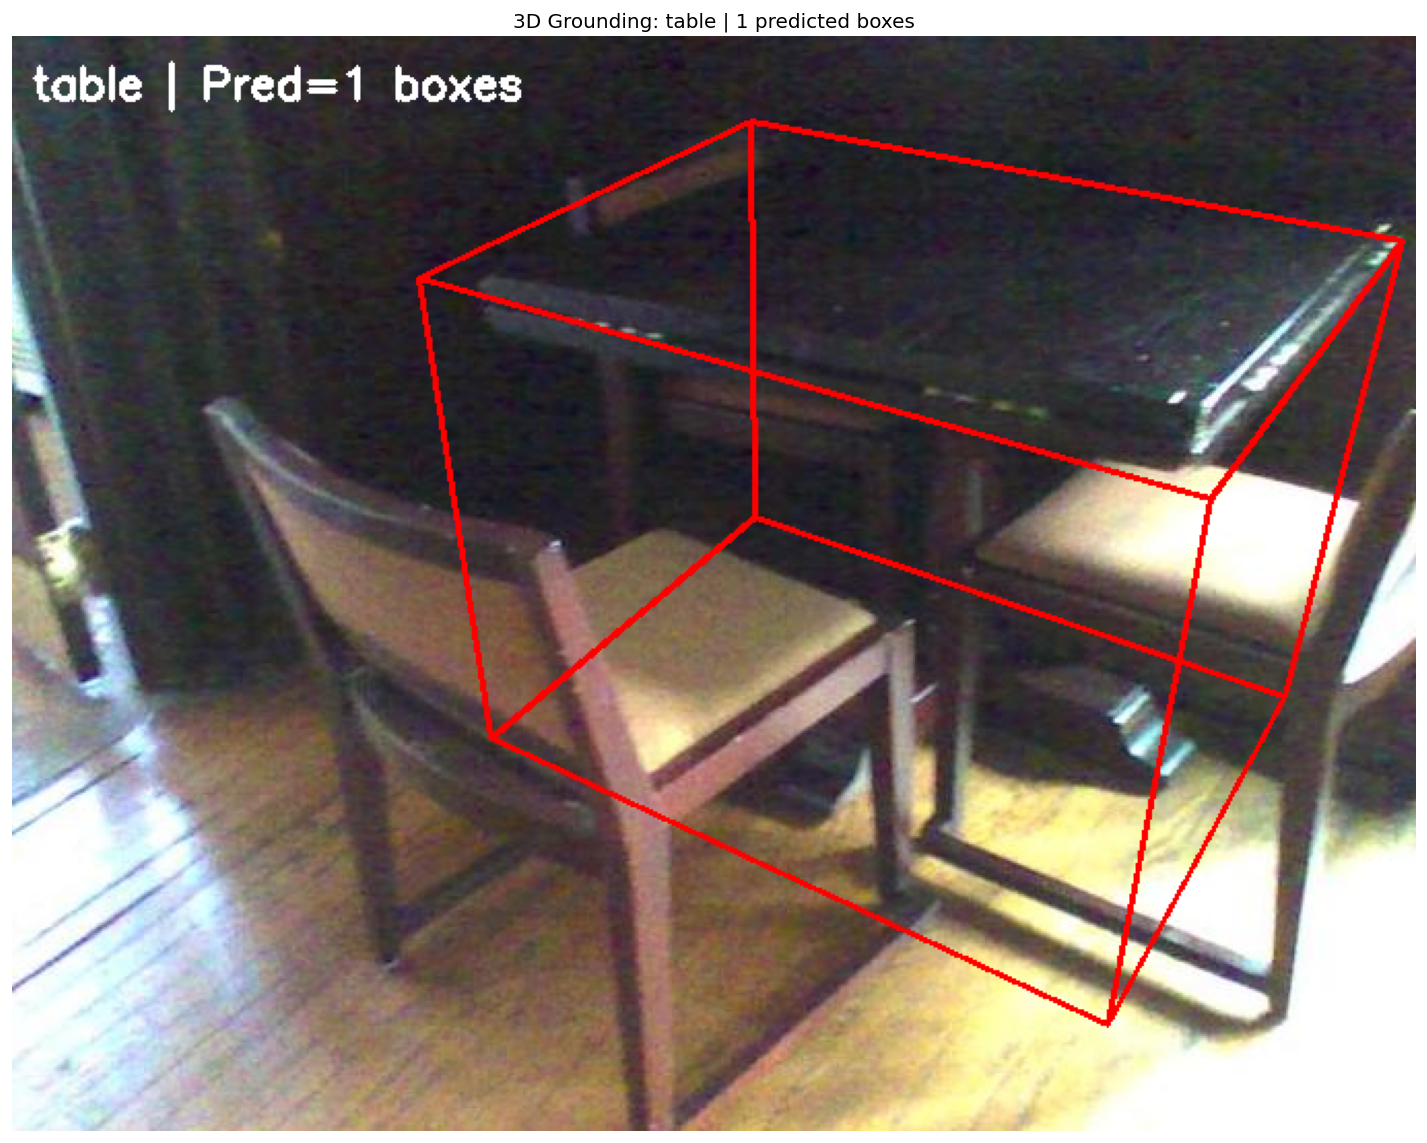

In [14]:
# Load table scene
table_image = "assets/3d_grounding/images/table_sunrgbd.jpg"
table_name = os.path.basename(table_image)
cam_info = cam_infos[table_name]
K_table = np.array([
    [cam_info["fx"], 0.0, cam_info["cx"]],
    [0.0, cam_info["fy"], cam_info["cy"]],
    [0.0, 0.0, 1.0]
])

# Detect table
cat2 = "table"
K_str_table = format_K(K_table)
prompt = build_3d_grounding_prompt(cat2, K_str_table)

# Inference
output_text = run_inference(wrapper, table_image, prompt, PROCESSING_PARAMS, SAMPLING_PARAMS)
print(output_text)

# Parse and visualize
parsed_boxes = parse_3d_groundings(output_text)
print(f"\nDetected {len(parsed_boxes)} {cat2}(s)")

if parsed_boxes:
    visualize_3d_grounding(table_image, K_table, parsed_boxes, cat2)

### Custom Test

You can test 3D grounding with your own images. Here's a template:

1. **Prepare your image**: Place it in `assets/3d_grounding/images/` or use any accessible path

2. **Get camera intrinsics**: Add to `sunrgbd_cam_infos.json` with keys: `fx`, `fy`, `cx`, `cy`, or manually define the 3x3 matrix K

3. **Run inference**: Use the code pattern below

[transformers] Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Testing on: assets/3d_grounding/images/chair_sunrgbd.jpg
Category: chair
Intrinsics:
[[529.5   0.  365. ]
 [  0.  529.5 265. ]
 [  0.    0.    1. ]]
<3D Grounding> -0.15, 0.05, 1.45, 0.72, 1.00, 0.68, 0.28, 0.15, 0.17 </3D Grounding>


Detected 1 chair(s)
Box 1: center=[-0.15, 0.05, 1.45], dims=[0.72, 1.0, 0.68]


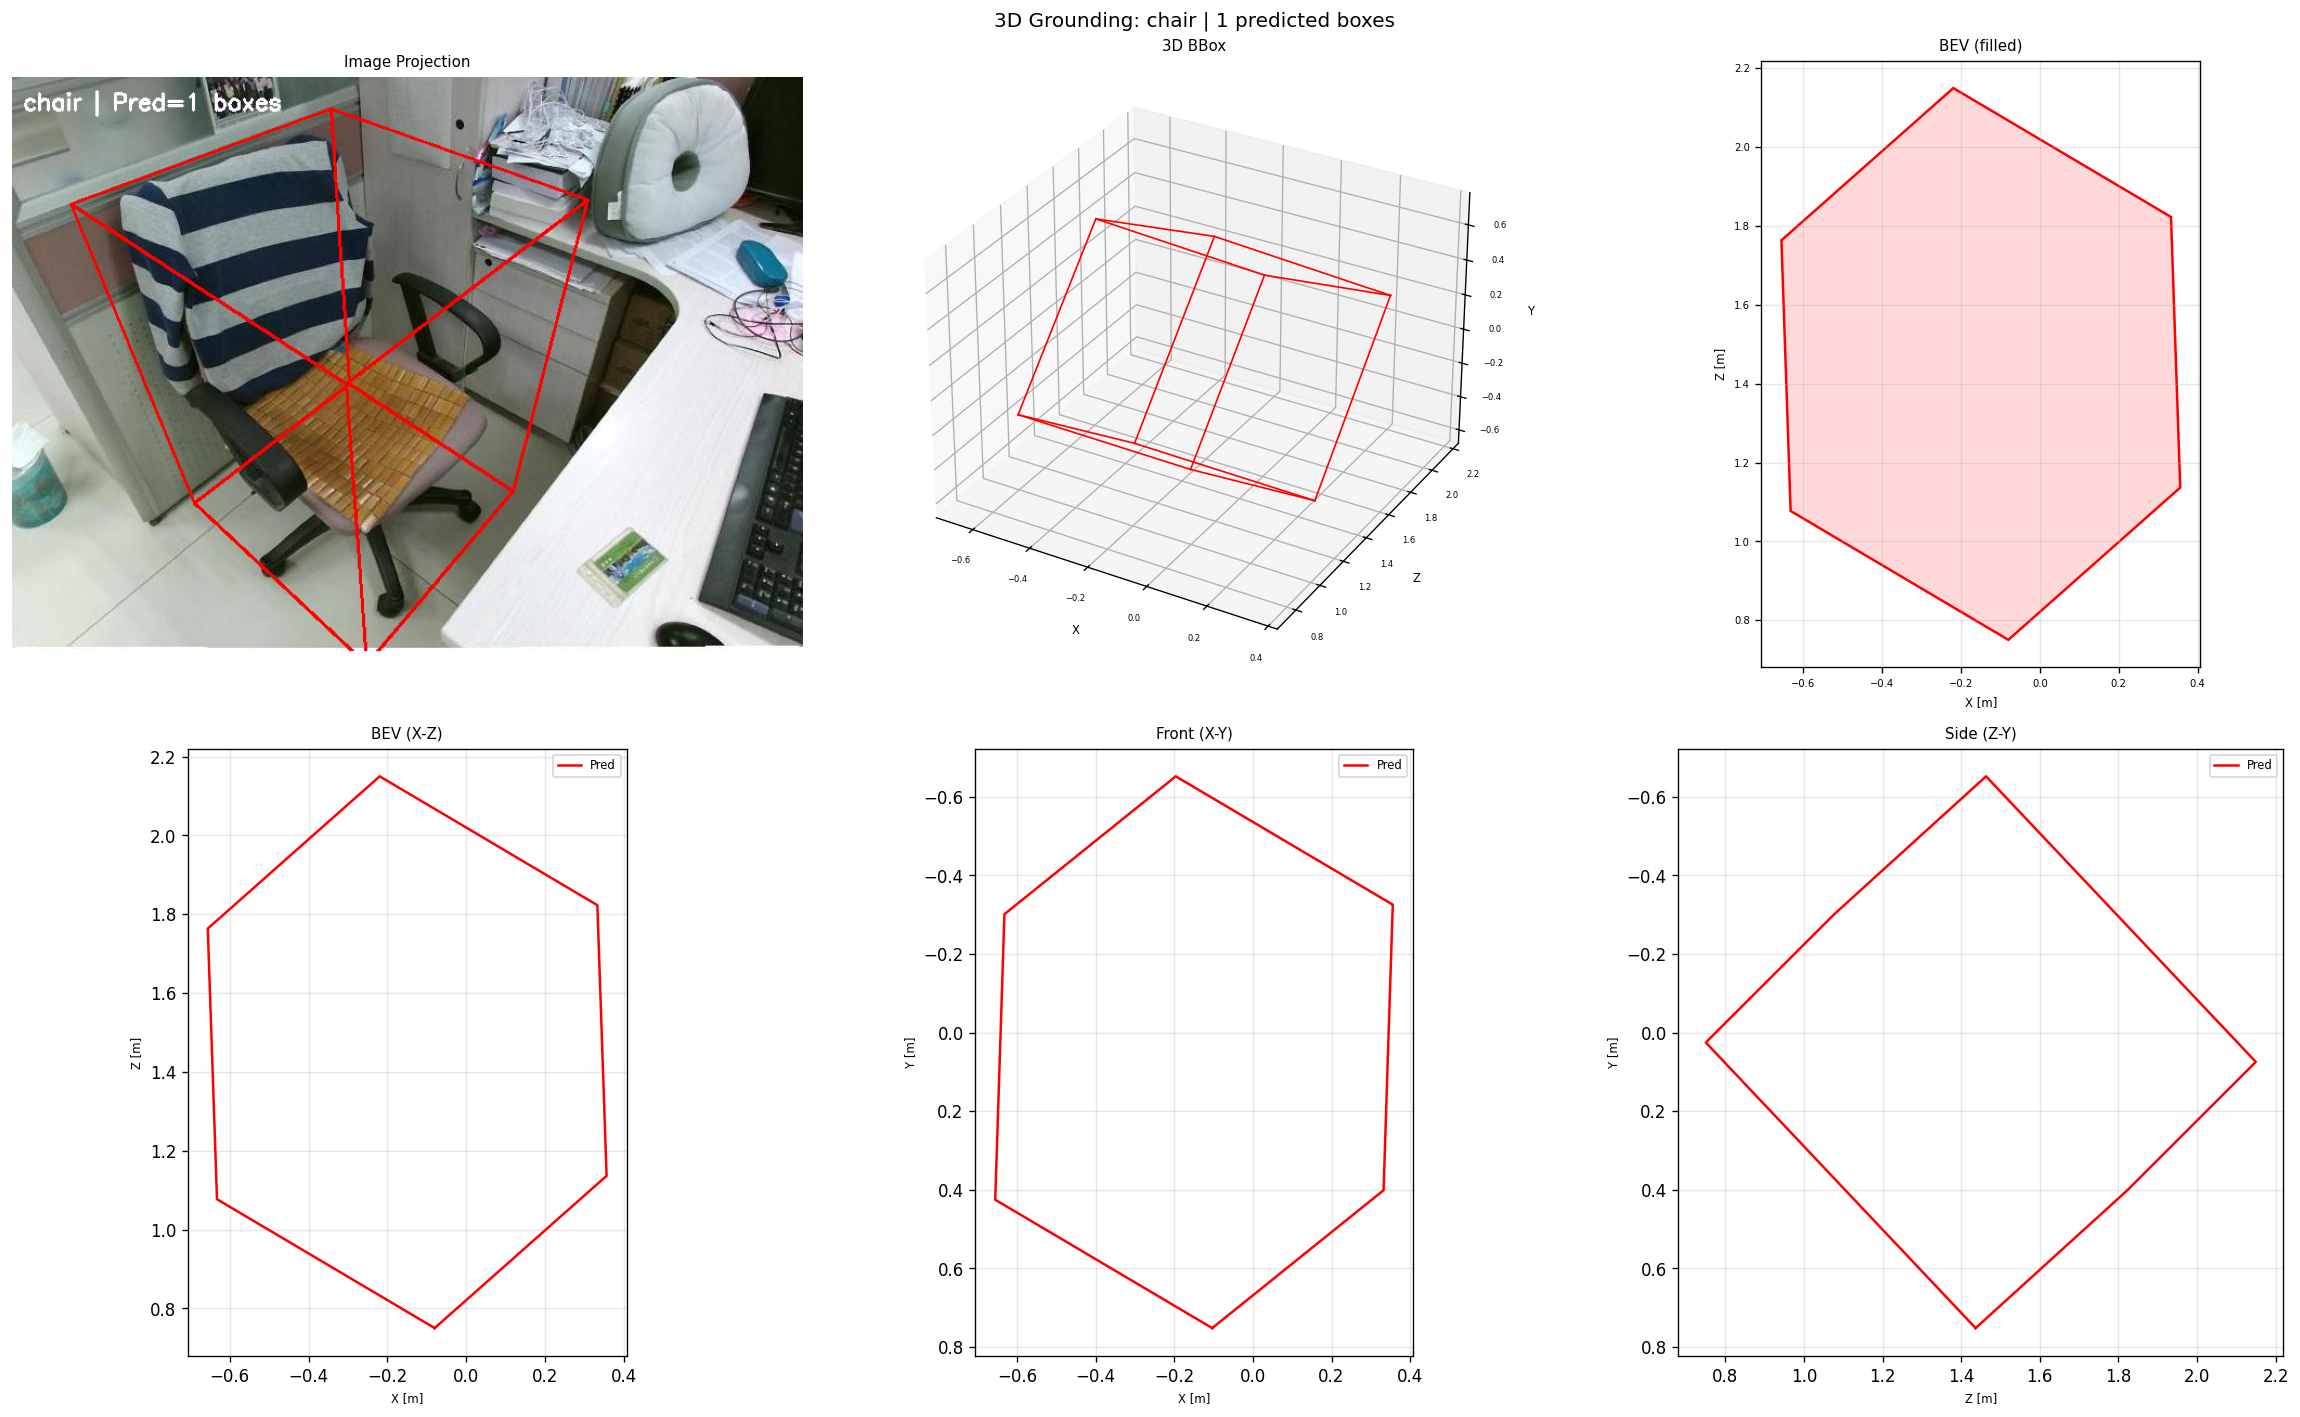

In [10]:
# Template for custom testing
custom_image = "assets/3d_grounding/images/chair_sunrgbd.jpg"  # Change to your image
custom_category = "chair"  # Change to target category (e.g., chair, bed, table, desk, sofa, night_stand, dresser, bookshelf, toilet, bathtub)

# Load camera params
custom_name = os.path.basename(custom_image)
if custom_name in cam_infos:
    info = cam_infos[custom_name]
    K_custom = np.array([
        [info["fx"], 0.0, info["cx"]],
        [0.0, info["fy"], info["cy"]],
        [0.0, 0.0, 1.0]
    ])
else:
    # Fallback: assume 60 deg FOV, center at image middle
    img_temp = Image.open(custom_image)
    w, h = img_temp.size
    f = max(w, h) / (2 * np.tan(np.deg2rad(30)))
    K_custom = np.array([[f, 0.0, w/2], [0.0, f, h/2], [0.0, 0.0, 1.0]])
    print(f"Using fallback intrinsics (assumed 60 deg FOV)")

print(f"Testing on: {custom_image}")
print(f"Category: {custom_category}")
print(f"Intrinsics:\n{K_custom}")

# Build prompt and run
K_str_custom = format_K(K_custom)
prompt = build_3d_grounding_prompt(custom_category, K_str_custom)

# Inference
output_text = run_inference(wrapper, custom_image, prompt, PROCESSING_PARAMS, SAMPLING_PARAMS)
print(output_text)

# Parse and visualize
parsed_boxes = parse_3d_groundings(output_text)
print(f"\nDetected {len(parsed_boxes)} {custom_category}(s)")

if parsed_boxes:
    for i, box in enumerate(parsed_boxes):
        print(f"Box {i+1}: center={box['center']}, dims={box['dims']}")
    visualize_3d_grounding(custom_image, K_custom, parsed_boxes, custom_category)